In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('/content/Financial_ratios.csv',index_col=0).drop(columns=['close_quarter_after'])

In [ ]:
prices=pd.read_csv('/content/prices.csv',index_col=0)

In [ ]:
prices

,time,ticker,close,returns,year,quarter
1,2020-01-03,ACB,6.64,0.000000,2020,1
2,2020-01-06,ACB,6.49,-0.022590,2020,1
3,2020-01-07,ACB,6.49,0.000000,2020,1
4,2020-01-08,ACB,6.38,-0.016949,2020,1
5,2020-01-09,ACB,6.46,0.012539,2020,1
...,...,...,...,...,...,...
1245,2024-12-25,VNM,61.71,0.001461,2024,4
1246,2024-12-26,VNM,61.62,-0.001458,2024,4
1247,2024-12-27,VNM,61.62,0.000000,2024,4
1248,2024-12-30,VNM,61.14,-0.007790,2024,4


In [ ]:
data

,year,quarter,ticker,close,forward_return,size,de,roe,roa
0,2015,1,ACB,2.55,0.282353,32.863793,13.772336,0.000000,0.000000
1,2015,2,ACB,3.27,-0.051988,32.875391,14.353217,0.000000,0.000000
2,2015,3,ACB,3.10,0.019355,32.893695,14.298959,0.000000,0.000000
3,2015,4,ACB,3.16,-0.075949,32.936597,14.754160,0.000000,0.000000
4,2016,1,ACB,2.92,0.037671,32.977499,15.016311,0.083376,0.005341
...,...,...,...,...,...,...,...,...,...
635,2023,4,SHB,8.98,0.055679,34.077415,11.638862,0.157517,0.012490
636,2024,1,SHB,9.48,0.000000,34.062584,10.679818,0.155816,0.012824
637,2024,2,SHB,9.48,0.007384,34.123051,10.762857,0.155879,0.012975
638,2024,3,SHB,9.55,-0.068063,34.165372,11.347513,0.145429,0.012022


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

def train_alpha_model(df, year):
    """
    Huấn luyện mô hình RandomForest dự đoán ROE từ dữ liệu đến hết năm 'year'.
    Trả về mô hình đã train.
    """

    train_data = df[df['year'] <= year]
    X_train = train_data[[ 'size','roa']]# data có 'size', 'de', 'roa'
    y_train = train_data['forward_return']

    model = RandomForestRegressor(n_estimators=100, random_state=10)
    model.fit(X_train, y_train)

    return model


In [ ]:
def predict_alpha_portfolio(df, model, predict_year):
    """
    Sử dụng mô hình đã train để dự báo ROE cho từng quý trong năm 'predict_year'.
    Trả về DataFrame portfolio có dạng MultiIndex (year, quarter) x ticker với weight.
    """
    portfolios = pd.DataFrame()

    for quarter in range(1, 5):
        try:
            test_data = df[(df['year'] == predict_year) & (df['quarter'] == quarter)]
            if test_data.empty:
                continue

            X_test = test_data[['size','roa']]# data có 'size', 'de', 'roa'
            y_pred = model.predict(X_test)

            portfolio = pd.DataFrame({
                'ticker': test_data['ticker'].values,
                'roe_pred': y_pred
            })

            # Normalize + chuẩn hóa + tính weight
            portfolio['ranked'] = portfolio['roe_pred'] / portfolio['roe_pred'].mean()
            mu = portfolio['ranked'].mean()
            sigma = portfolio['ranked'].std()
            portfolio['zscore'] = (portfolio['ranked'] - mu) / sigma
            portfolio['weight'] = portfolio['zscore'] / portfolio['zscore'].abs().sum()
            portfolio['year'] = predict_year+1
            portfolio['quarter'] = quarter

            # Chuyển thành dạng bảng (year, quarter) x ticker
            portfolio = portfolio.pivot(index=['year', 'quarter'], columns='ticker', values='weight')
            portfolios = pd.concat([portfolios, portfolio])
        except Exception as e:
            continue

    return portfolios


In [ ]:
def calculate_portfolio_metrics(portfolio_df, daily_returns_df, year=2020, risk_free_rate=0):
    # Bước 1: Normalize weights theo từng quý
    normalized_weights = portfolio_df

    all_portfolio_returns = []

    for quarter in [1, 2, 3, 4]:
        try:
            # Lấy trọng số quý này
            weights = normalized_weights.loc[(year, quarter)].dropna()
            tickers = weights.index.tolist()

            # Lọc return theo quý và ticker
            quarter_returns = daily_returns_df[
                (daily_returns_df['year'] == year) &
                (daily_returns_df['quarter'] == quarter) &
                (daily_returns_df['ticker'].isin(tickers))
            ].copy()

            # Tạo pivot bảng return time x ticker
            pivot_returns = quarter_returns.pivot(index='time', columns='ticker', values='returns')
            pivot_returns = pivot_returns[weights.index]  # Giữ đúng ticker theo weights
            pivot_returns = pivot_returns.dropna(how='any')  # Loại bỏ ngày có thiếu dữ liệu

            # Nhân với trọng số
            weighted_returns = pivot_returns.mul(weights, axis=1)

            # Tính daily return
            daily_portfolio_return = weighted_returns.sum(axis=1).reset_index()
            daily_portfolio_return.columns = ['time', 'portfolio_return']

            all_portfolio_returns.append(daily_portfolio_return)

        except Exception as e:
            print(f"Quý {quarter} bị lỗi: {e}")
            continue

    # Gộp tất cả các quý
    if all_portfolio_returns:
        full_year_return_df = pd.concat(all_portfolio_returns, axis=0).sort_values('time')
    else:
        raise ValueError(f"Không có dữ liệu portfolio return nào cho năm {year}")


    # Bước 3: Tính cumulative return
    full_year_return_df['cumulative_return'] = (1 + full_year_return_df['portfolio_return']).cumprod()

    # Tính Sharpe ratio
    mean_return = full_year_return_df['portfolio_return'].mean()
    std_return = full_year_return_df['portfolio_return'].std()
    sharpe_ratio = (252 * mean_return - risk_free_rate) / (np.sqrt(252) * std_return)

    # Tính Total return
    total_return = full_year_return_df['cumulative_return'].iloc[-1] - 1

    # Max Drawdown
    cumulative = full_year_return_df['cumulative_return']
    running_max = cumulative.cummax()
    drawdowns = (cumulative - running_max) / running_max
    max_drawdown = drawdowns.min()

    return {
        'Sharpe Ratio': sharpe_ratio,
        'Standard Deviation (%)': std_return * 100,
        'Total Return (%)': total_return * 100,
        'Max Drawdown (%)': -max_drawdown * 100,
        'Cumulative Returns': full_year_return_df
    }

## Danh mục phân bổ theo Markowitz

In [ ]:
from scipy.optimize import minimize
import pandas as pd
import numpy as np

def markowitz_allocation(df, year=2020):
    """
    Phân bổ danh mục đầu tư theo Markowitz theo từng quý từ dữ liệu dạng long format.

    Parameters:
        df (pd.DataFrame): DataFrame chứa các cột ['time', 'ticker', 'returns'].
        year (int): Năm cần phân bổ.

    Returns:
        pd.DataFrame: DataFrame chứa các trọng số phân bổ Markowitz theo từng quý.
    """

    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])

    # ✅ Lọc theo năm chính xác
    df = df[df['time'].dt.year == year]

    # Pivot: time = index, ticker = columns, values = returns
    df_pivot = df.pivot(index='time', columns='ticker', values='returns')

    # Tạo cột quý từ index datetime
    df_pivot['quarter'] = df_pivot.index.quarter

    allocations = []

    for quarter, data in df_pivot.groupby('quarter'):
        returns_q = data.drop(columns='quarter')

        # ✅ Giữ lại các cổ phiếu đầy đủ dữ liệu trong quý
        returns_q = returns_q.dropna(axis=0, how='any')

        if returns_q.empty:
            print(f"[!] Quý {quarter}: Không đủ dữ liệu ngày.")
            continue

        # ✅ Giữ lại chỉ các cổ phiếu có đủ dữ liệu
        returns_q = returns_q.dropna(axis=1, how='any')
        tickers = returns_q.columns.tolist()

        if len(tickers) < 2:
            print(f"[!] Quý {quarter}: Chỉ có {len(tickers)} cổ phiếu, không đủ để tối ưu.")
            continue

        def portfolio_variance(weights):
            return weights.T @ returns_q.cov().values @ weights

        constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        bounds = [(0, 1) for _ in tickers]
        init_weights = np.array([1 / len(tickers)] * len(tickers))

        result = minimize(portfolio_variance, init_weights,
                          method='SLSQP', bounds=bounds, constraints=constraints)

        if result.success:
            weight_dict = dict(zip(tickers, result.x.round(4)))
            weight_dict['quarter'] = quarter
            weight_dict['year'] = year+1
            allocations.append(weight_dict)
        else:
            print(f"[X] Tối ưu thất bại ở quý {quarter}")

    if not allocations:
        print("Không có quý nào được tối ưu.")
        return pd.DataFrame()

    df_alloc = pd.DataFrame(allocations).set_index(['year', 'quarter'])
    return df_alloc.fillna(0)

## Backtest kết quả 2 mô hình

In [ ]:
# Khởi tạo
previous_alpha_model = None
use_previous_model = False

results = []

for train_year in range(2020, 2024):  # Huấn luyện với train_year => Dự báo cho test_year
    test_year = train_year + 1
    print(f"\n--- Train Year {train_year} | Test Year {test_year} ---")

    if not use_previous_model:
        # Nếu Alpha thua ở năm trước, ta huấn luyện lại mô hình mới
        alpha_model = train_alpha_model(data, year=train_year)
    else:
        # Nếu Alpha thắng, tiếp tục dùng model cũ
        alpha_model = previous_alpha_model

    # Dự báo danh mục phân bổ cho test_year
    alpha_portfolio = predict_alpha_portfolio(data, alpha_model, predict_year=train_year)

    # Dự báo Markowitz luôn dùng lại mỗi năm
    markowitz_port = markowitz_allocation(prices, year=train_year)

    # Đánh giá cả hai danh mục ở test_year
    alpha_metrics = calculate_portfolio_metrics(alpha_portfolio, prices, year=test_year, risk_free_rate=0.029)
    markowitz_metrics = calculate_portfolio_metrics(markowitz_port, prices, year=test_year, risk_free_rate=0.029)

    # In kết quả
    print("Alpha Sharpe Ratio:", alpha_metrics['Sharpe Ratio'])
    print("Alpha Total Return (%):", alpha_metrics['Total Return (%)'])
    print("Alpha Max Drawdown (%):", alpha_metrics['Max Drawdown (%)'])
    print('===================================')
    print("Markowitz Sharpe Ratio:", markowitz_metrics['Sharpe Ratio'])
    print("Markowitz Total Return (%):", markowitz_metrics['Total Return (%)'])
    print("Markowitz Max Drawdown (%):", markowitz_metrics['Max Drawdown (%)'])

    # So sánh hiệu suất
    if alpha_metrics['Sharpe Ratio'] >= markowitz_metrics['Sharpe Ratio']:
        print("✅ Alpha thắng → tiếp tục dùng mô hình này cho năm sau.")
        previous_alpha_model = alpha_model
        use_previous_model = True
    else:
        print("❌ Alpha thua → retrain mô hình ở năm sau.")
        previous_alpha_model = None
        use_previous_model = False

    # Lưu kết quả
    results.append({
        'train_year': train_year,
        'test_year': test_year,
        'alpha_sharpe': alpha_metrics['Sharpe Ratio'],
        'alpha_return': alpha_metrics['Total Return (%)'],
        'alpha_max_dd': alpha_metrics['Max Drawdown (%)'],
        'markowitz_sharpe': markowitz_metrics['Sharpe Ratio'],
        'markowitz_return': markowitz_metrics['Total Return (%)'],
        'markowitz_max_dd': markowitz_metrics['Max Drawdown (%)'],
        'used_previous_model': use_previous_model
    })


--- Train Year 2020 | Test Year 2021 ---
Alpha Sharpe Ratio: 1.814762281919564
Alpha Total Return (%): 22.8080688448423
Alpha Max Drawdown (%): 6.369040475018731
Markowitz Sharpe Ratio: 1.4493656210197507
Markowitz Total Return (%): 42.484352359833856
Markowitz Max Drawdown (%): 17.41929614800548
✅ Alpha thắng → tiếp tục dùng mô hình này cho năm sau.

--- Train Year 2021 | Test Year 2022 ---
Alpha Sharpe Ratio: -2.1101970299914217
Alpha Total Return (%): -16.547461079348167
Alpha Max Drawdown (%): 21.440987264423075
Markowitz Sharpe Ratio: -0.8488374417318356
Markowitz Total Return (%): -22.986065875239202
Markowitz Max Drawdown (%): 36.10989758651635
❌ Alpha thua → retrain mô hình ở năm sau.

--- Train Year 2022 | Test Year 2023 ---
Alpha Sharpe Ratio: 2.7042385175074473
Alpha Total Return (%): 30.886398311525287
Alpha Max Drawdown (%): 5.938655240918267
Markowitz Sharpe Ratio: 0.30755732197786173
Markowitz Total Return (%): 6.934959120937911
Markowitz Max Drawdown (%): 16.8348971090

In [ ]:
# Tạo DataFrame tổng hợp kết quả
results_df = pd.DataFrame(results)
print("\n📊 Tổng hợp kết quả:")
results_df



📊 Tổng hợp kết quả:


,train_year,test_year,alpha_sharpe,alpha_return,alpha_max_dd,markowitz_sharpe,markowitz_return,markowitz_max_dd,used_previous_model
0,2020,2021,1.814762,22.808069,6.369040,1.449366,42.484352,17.419296,True
1,2021,2022,-2.110197,-16.547461,21.440987,-0.848837,-22.986066,36.109898,False
2,2022,2023,2.704239,30.886398,5.938655,0.307557,6.934959,16.834897,True
3,2023,2024,0.255462,4.156804,4.276786,1.105653,19.312364,9.016528,False


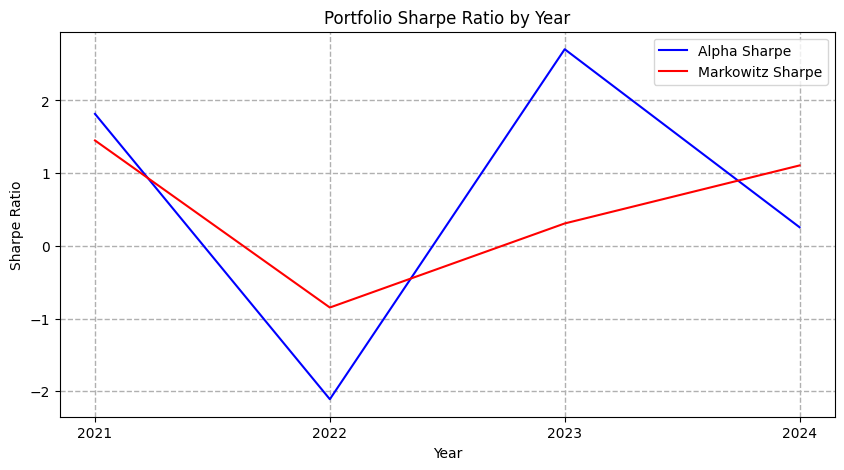

In [ ]:
import matplotlib.pyplot as plt
BLUE1 = 'blue'
RED1="red"
plt.figure(figsize=(10,5),dpi=100)
plt.plot(results_df['test_year'],results_df['alpha_sharpe'], color=BLUE1, label='Alpha Sharpe')
plt.plot(results_df['test_year'],results_df['markowitz_sharpe'], color=RED1, label='Markowitz Sharpe')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Year')
plt.grid(True, linestyle='--', linewidth=1)
plt.title('Portfolio Sharpe Ratio by Year')
plt.xticks(np.arange(2021,2025,1))
plt.legend()
plt.savefig('sharpe_ratio_by_year.png', bbox_inches='tight', dpi=300)
plt.show() # Hiển thị biểu đồ

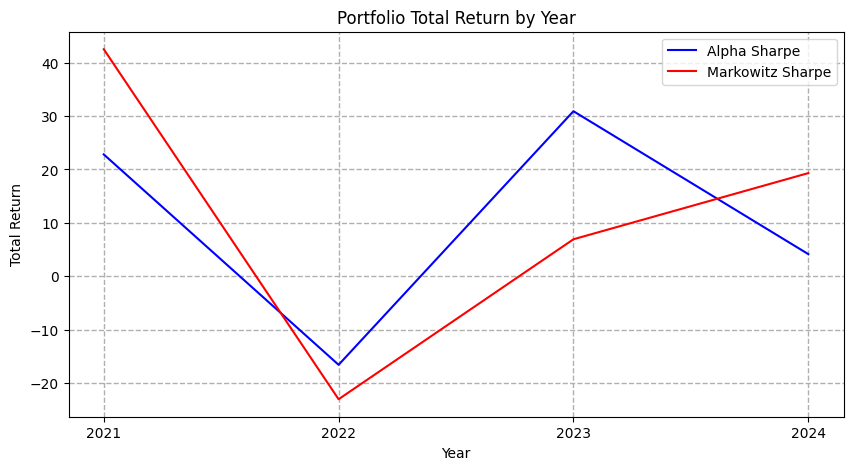

In [ ]:
import matplotlib.pyplot as plt
BLUE1 = 'blue'
RED1="red"
plt.figure(figsize=(10,5),dpi=100)
plt.plot(results_df['test_year'],results_df['alpha_return'], color=BLUE1, label='Alpha Sharpe')
plt.plot(results_df['test_year'],results_df['markowitz_return'], color=RED1, label='Markowitz Sharpe')
plt.ylabel('Total Return')
plt.xlabel('Year')
plt.grid(True, linestyle='--', linewidth=1)
plt.title('Portfolio Total Return by Year')
plt.xticks(np.arange(2021,2025,1))
plt.legend()
plt.savefig('total_return_by_year.png', bbox_inches='tight', dpi=300)
plt.show() # Hiển thị biểu đồ

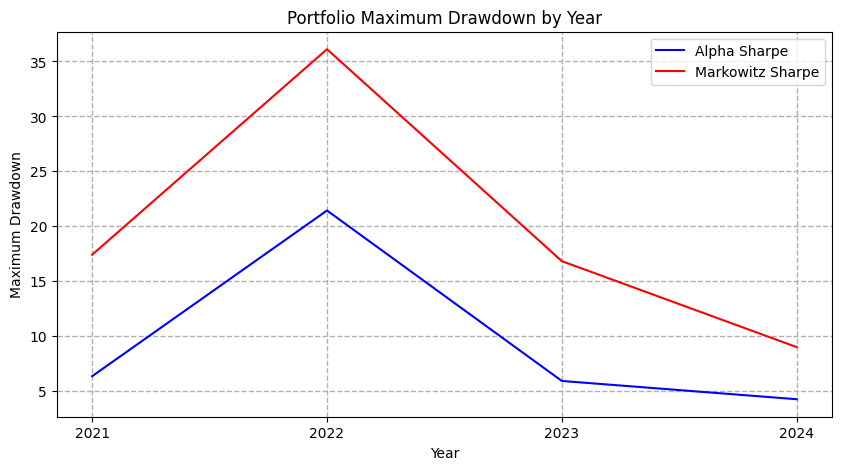

In [ ]:
import matplotlib.pyplot as plt
BLUE1 = 'blue'
RED1="red"
plt.figure(figsize=(10,5),dpi=100)
plt.plot(results_df['test_year'],results_df['alpha_max_dd'], color=BLUE1, label='Alpha Sharpe')
plt.plot(results_df['test_year'],results_df['markowitz_max_dd'], color=RED1, label='Markowitz Sharpe')
plt.ylabel('Maximum Drawdown')
plt.xlabel('Year')
plt.grid(True, linestyle='--', linewidth=1)
plt.title('Portfolio Maximum Drawdown by Year')
plt.xticks(np.arange(2021,2025,1))
plt.legend()
plt.savefig('max_drawdown_by_year.png', bbox_inches='tight', dpi=300)
plt.show() # Hiển thị biểu đồ